<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">REDES NEURONALES RECURRENTES</strong>
</div>

# Redes Neuronales Recurrentes **RNN**

## Keras

### Ejemplo con una capa RNN

---

### Definición de parámetros principales
- **Vocabulario**: se define como 

  $$ V = \{h, e, l, o\}, \quad |V| = 4 $$  

  donde $|V|$ indica el tamaño del vocabulario.  

- **Diccionarios de conversión**:  
  - $char\_to\_idx$: asigna a cada carácter un índice entero, por ejemplo:  

    $$ \{ h \mapsto 0,\ e \mapsto 1,\ l \mapsto 2,\ o \mapsto 3 \} $$  

  - $idx\_to\_char$: permite la conversión inversa, es decir, de índices a caracteres.  

- **Longitud de la secuencia ($maxlen$)**: se establece $maxlen = 1$, lo que significa que cada entrada al modelo corresponde a un único carácter. El objetivo es que la red aprenda a predecir el carácter siguiente.  

- **Número de neuronas ($units$)**: se define $units = 8$, lo cual determina la dimensión del **estado oculto** en la capa recurrente `SimpleRNN`.  

---

In [1]:
# ============================================
# Librerías necesarias
# ============================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# ============================================
# Definir parámetros principales
# ============================================
vocab = ['h', 'e', 'l', 'o']   # vocabulario
vocab_size = len(vocab)        # = 4
char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for i, c in enumerate(vocab)}

maxlen = 1    # cada entrada será un carácter
units = 8     # número de neuronas en la capa recurrente

print("Vocabulario:", vocab)
print("Diccionario:", char_to_idx)


ModuleNotFoundError: No module named 'numpy'

### Preparación de los datos de entrenamiento

#### Conversión de caracteres a índices
La palabra `"hello"` se transforma en una secuencia de índices enteros utilizando el diccionario $char\_to\_idx$:  
$$
\text{"hello"} \;\;\to\;\; [0, 1, 2, 2, 3]
$$  
donde, por ejemplo, $h \mapsto 0$, $e \mapsto 1$, $l \mapsto 2$, $o \mapsto 3$.

#### Construcción de pares entrada–salida
Se generan los pares para que la red aprenda a predecir el siguiente carácter:  
- Entradas: `["h", "e", "l", "l"]` $\;\to\;$ $[0,1,2,2]$  
- Salidas:  `["e", "l", "l", "o"]` $\;\to\;$ $[1,2,2,3]$  
> De manera general, si la secuencia es  $[s_0, s_1, s_2, \dots, s_T],$  
> entonces las entradas corresponden a  $[s_0, s_1, \dots, s_{T-1}],$  
> y las salidas a $[s_1, s_2, \dots, s_T].$  

#### Representación *one-hot*
Cada índice se convierte en un vector *one-hot* de dimensión igual al tamaño del vocabulario ($|V| = 4$).  
- Las entradas $X$ quedan con forma:  $(4, 1, 4)$:
1. El primer valor $4$ indica el número de ejemplos (muestras) (cada carácter de entrada: ``h``, ``e``, ``l``, ``l``).  
2. El segundo valor $1$ corresponde a la longitud de la secuencia, por ejemplo 1, ya que se definió `maxlen = 1`. Cada ejemplo contiene un único carácter.  
3. El tercer valor $4$ representa el tamaño ($d$) del vector *one-hot*, que coincide con el tamaño del vocabulario $|V| = 4$ (dimensión del vector de caractarísiticas).  

- Las salidas $Y$ quedan con forma:  $(4, 4)$: 
1. El primer valor $4$ corresponde al número de ejemplos (muestras) de salida, uno por cada entrada.  
2. El segundo valor $4$ corresponde al vector *one-hot* que representa la clase correcta (la siguiente letra en la secuencia) dentro del vocabulario.  


In [ ]:
# ============================================
# Preparar los datos 
#    se construyen las entradas (X) y las salidas (Y) que alimentarán a la red neuronal,
#    a partir de la secuencia "hello".
# ============================================
sequence = "hello"

# Convertir de caracteres a índices
#     La palabra "hello" se transforma en una secuencia de índices enteros 
#     utilizando el diccionario char_to_idx:  

seq_indices = [char_to_idx[c] for c in sequence]   # ejemplo: [0,1,2,2,3] según el vocab
print("Secuencia de índices:", seq_indices)

# Generar pares entradas-salidas, para el aprendizaje
# Entrada: "h","e","l","l"
# Salida:  "e","l","l","o"
X_idx = seq_indices[:-1]  # [0,1,2,2]
Y_idx = seq_indices[1:]   # [1,2,2,3]


# One-hot encoding de entradas y salidas
X = to_categorical(X_idx, num_classes=vocab_size).reshape(len(X_idx), maxlen, vocab_size)
Y = to_categorical(Y_idx, num_classes=vocab_size).reshape(len(Y_idx), vocab_size)

print("Forma de X: (Numero de secuencias (batch), Longitud de cada secuencia, Numero de caracteristcas por cada paso temporal")
print("\nForma de X:", X.shape)
print("Forma de y:", Y.shape)

# Secuencia de entrada como índices
print("\nSecuencia de entrada (índices):", X_idx)

# Secuencia de entrada como caracteres
input_chars = [idx_to_char[i] for i in X_idx]
print("Secuencia de entrada (caracteres):", input_chars)

# Secuencia de entrada como vectores one-hot (pixeles)
print("\nSecuencia de entrada (vectores one-hot / pixeles):")
for i, vec in enumerate(X):
    print(f"{input_chars[i]} -> {vec[0]}")


Secuencia de índices: [0, 1, 2, 2, 3]
Forma de X: (Numero de secuencias (batch), Longitud de cada secuencia, Numero de caracteristcas por cada paso temporal

Forma de X: (4, 1, 4)
Forma de y: (4, 4)

Secuencia de entrada (índices): [0, 1, 2, 2]
Secuencia de entrada (caracteres): ['h', 'e', 'l', 'l']

Secuencia de entrada (vectores one-hot / pixeles):
h -> [1. 0. 0. 0.]
e -> [0. 1. 0. 0.]
l -> [0. 0. 1. 0.]
l -> [0. 0. 1. 0.]


### Definición del modelo RNN simple

#### Arquitectura del modelo
El modelo se define como una red secuencial compuesta por dos capas principales:

1. **Capa recurrente (`SimpleRNN`)**  
   - Número de unidades (neuronas ocultas): $units = 8$  
   - Dimensión de la entrada: $(maxlen, vocab\_size) = (1, 4)$  
   - Esta capa procesa secuencias de un carácter (debido a que $maxlen = 1$), generando una representación interna en un espacio de 8 dimensiones.

2. **Capa densa de salida (`Dense`)**  
   - Número de neuronas: $vocab\_size = 4$  
   - Activación: *softmax*, que convierte la salida en una distribución de probabilidad sobre los 4 caracteres posibles del vocabulario.

#### Función de pérdida y optimizador
- **Pérdida:** `categorical_crossentropy`, adecuada para clasificación multiclase.  
- **Optimizador:** `Adam`, que combina eficiencia y estabilidad en el entrenamiento.  
- **Métrica:** `accuracy`, para evaluar la proporción de predicciones correctas.

In [ ]:
# ============================================
# Definir el modelo RNN simple
# ============================================
model = tf.keras.Sequential([ # permite construir la red capa por capa,
                              # donde la salida de una capa es la entrada de la siguiente.
    tf.keras.layers.SimpleRNN(units, input_shape=(maxlen, vocab_size)),
    tf.keras.layers.Dense(vocab_size, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

C:\Users\Flavio\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
for i, layer in enumerate(model.layers):
    print(f"\nCapa {i+1}: {layer.name}")
    
    for var in layer.trainable_variables:
        print(f"{var.name} -> Forma: {var.shape}")


Capa 1: simple_rnn
kernel -> Forma: (4, 8)
recurrent_kernel -> Forma: (8, 8)
bias -> Forma: (8,)

Capa 2: dense
kernel -> Forma: (8, 4)
bias -> Forma: (4,)


#### Cálculo de parámetros entrenables
1. **Capa `SimpleRNN`:**  
   Cada neurona de la RNN tiene tres conjuntos de pesos:  
   - Matriz de pesos de entrada: $(vocab\_size \times units) = (4 \times 8) = 32$  
   - Matriz de pesos recurrentes: $(units \times units) = (8 \times 8) = 64$  
   - Bias: $units = 8$  
   - **Total por RNN:** $32 + 64 + 8 = 104$ parámetros.

2. **Capa `Dense`:**  
   - Pesos: $(units \times vocab\_size) = (8 \times 4) = 32$  
   - Bias: $vocab\_size = 4$  
   - **Total Dense:** $32 + 4 = 36$ parámetros.

3. **Total del modelo:**  
   $104 + 36 = 140$ parámetros entrenables.

#### Resumen de capas
- Entrada: $(1, 4)$  
- `SimpleRNN(8)` $\;\to\;$ salida de dimensión $(8)$ con **104 parámetros**  
- `Dense(4)` $\;\to\;$ salida softmax $(4)$ con **36 parámetros**  
- **Parámetros totales: 140**

In [ ]:
# ============================================
# Mostrar resumen
# ============================================

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)

### Parámetros del optimizador Adam

- Al compilar el modelo con el optimizador **Adam**, Keras reporta un número adicional de parámetros, llamados *Optimizer params*.  

- Por cada parámetro entrenable del modelo, Adam mantiene variables internas que permiten un ajuste adaptativo de la tasa de aprendizaje:

- $m_t$: estimación del **momento de primer orden** (media móvil de los gradientes).  
- $v_t$: estimación del **momento de segundo orden** (media móvil de los gradientes al cuadrado).  

Esto significa que por cada peso entrenable se guardan **2 parámetros adicionales**.

#### Cálculo en este ejemplo
- Parámetros entrenables del modelo:  
$$
\text{Trainable params} = 140
$$  

- Parámetros internos del optimizador:  
$$
\text{Optimizer params} = (2 \times \text{Trainable params}) + \text{pequeñas variables adicionales} = (2 \times 140) + 2 = 282
$$  

Las variables adicionales son variables utilizadas por Keras para manejar el estado interno del optimizador (p. ej. contadores o buffers).



In [ ]:
# ============================================
# Entrenamiento
# ============================================
print("\nEntrenando modelo...")
model.fit(X, Y, epochs=500, verbose=0)
print("\nFin de entrenamiento.")


Entrenando modelo...

Fin de entrenamiento.


In [ ]:
# ============================================
# Predicción y generación de texto
# ============================================
def generate_text(model, start_char, length=10):
    idx = char_to_idx[start_char]
    input_seq = to_categorical([idx], num_classes=vocab_size).reshape(1, 1, vocab_size)
    
    result = start_char
    
    for _ in range(length):
        preds = model.predict(input_seq, verbose=0)
        next_idx = np.argmax(preds[0])   # ahora la salida es directa (batch_size, vocab_size)
        next_char = idx_to_char[next_idx]
        
        result += next_char
        
        # Actualizar entrada con el nuevo carácter
        input_seq = to_categorical([next_idx], num_classes=vocab_size).reshape(1, 1, vocab_size)
    
    return result

print("\n=== Texto generado iniciando con 'h' ===")
print(generate_text(model, start_char="h", length=4))


=== Texto generado iniciando con 'h' ===
helll


## Ejemplo en Keras (3 capas RNN)

In [ ]:
# ============================================
# Importar librerías
# ============================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# ============================================
# Preparar los datos
# ============================================
# Texto de ejemplo
text = "hello"

# Diccionario de caracteres
chars = sorted(list(set(text)))   # ['e','h','l','o']
vocab_size = len(chars)           # 4
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for i,c in enumerate(chars)}

print("Vocabulario:", chars)
print("Diccionario:", char_to_idx)

# Crear secuencias de entrada (X) y salida (y)
X = []
y = []

for i in range(len(text)-1):
    X.append(char_to_idx[text[i]])     # carácter actual
    y.append(char_to_idx[text[i+1]])   # siguiente carácter

X = np.array(X)   # (4,)
y = np.array(y)   # (4,)

# Secuencia de entrada como caracteres
seq_chars = [idx_to_char[idx] for idx in X]
print("\nSecuencia de entrada como caracteres:", seq_chars)

# Secuencia de entrada como índices
print("Secuencia de entrada (índices):", X)

# One-hot para X y y
X_onehot = np.eye(vocab_size)[X]   # (4,4)
y_onehot = np.eye(vocab_size)[y]   # (4,4)

# 🔹 Añadir dimensión de tiempo a X: (N, 1, vocab_size)
X_onehot = X_onehot.reshape((X_onehot.shape[0], 1, vocab_size))

print("\nForma de X_onehot:", X_onehot.shape)  # (4,1,4)
print("Forma de y_onehot:", y_onehot.shape)    # (4,4)

# Secuencia de entrada como vectores one-hot (pixeles)
print("\nSecuencia de entrada (vectores one-hot / pixeles):")
for i, vec in enumerate(X_onehot):
    print(f"{input_chars[i]} -> {vec[0]}")

Vocabulario: ['e', 'h', 'l', 'o']
Diccionario: {'e': 0, 'h': 1, 'l': 2, 'o': 3}

Secuencia de entrada como caracteres: ['h', 'e', 'l', 'l']
Secuencia de entrada (índices): [1 0 2 2]

Forma de X_onehot: (4, 1, 4)
Forma de y_onehot: (4, 4)

Secuencia de entrada (vectores one-hot / pixeles):
h -> [0. 1. 0. 0.]
e -> [1. 0. 0. 0.]
l -> [0. 0. 1. 0.]
l -> [0. 0. 1. 0.]


In [ ]:
# ============================================
# Definir el modelo con 3 capas RNN
# ============================================
units = 8

model = Sequential([ # permite construir la red capa por capa,
                     # donde la salida de una capa es la entrada de la siguiente.
    SimpleRNN(units, return_sequences=True, input_shape=(1, vocab_size), name="RNN_1"),
    SimpleRNN(units, return_sequences=True, name="RNN_2"),
    SimpleRNN(units, name="RNN_3"),
    Dense(vocab_size, activation="softmax", name="Output")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# ============================================
# Mostrar resumen
# ============================================
print("\nResumen del modelo:\n")
model.summary()


# ============================================
# Ver pesos y estados
for i, layer in enumerate(model.layers):
    weights = layer.get_weights()
    print(f"\nCapa {i+1}: {layer.name}")
    for w in weights:
        print("Forma:", w.shape)


Resumen del modelo:



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ RNN_1 (SimpleRNN)                    │ (None, 1, 8)                │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ RNN_2 (SimpleRNN)                    │ (None, 1, 8)                │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ RNN_3 (SimpleRNN)                    │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 412 (1.61 KB)

 Trainable params: 412 (1.61 KB)

 Non-trainable params: 0 (0.00 B)


Capa 1: RNN_1
Forma: (4, 8)
Forma: (8, 8)
Forma: (8,)

Capa 2: RNN_2
Forma: (8, 8)
Forma: (8, 8)
Forma: (8,)

Capa 3: RNN_3
Forma: (8, 8)
Forma: (8, 8)
Forma: (8,)

Capa 4: Output
Forma: (8, 4)
Forma: (4,)


In [ ]:
# ============================================
# Entrenamiento
# ============================================
print("\nEntrenando modelo...")
history = model.fit(X_onehot, y_onehot, epochs=500, verbose=0)
print("\nFin de entrenamiento")


Entrenando modelo...

Fin de entrenamiento


In [ ]:
# ============================================
# Predicción y generación de texto
# ============================================
def generate_text(model, start_char, length=4):
    input_eval = np.eye(vocab_size)[[char_to_idx[start_char]]]
    input_eval = input_eval.reshape((1,1,vocab_size))  # (1,1,4)
    
    result = [start_char]
    for _ in range(length):
        predictions = model.predict(input_eval, verbose=0)
        next_index = np.argmax(predictions[0])
        next_char = idx_to_char[next_index]
        result.append(next_char)
        # actualizar entrada
        input_eval = np.eye(vocab_size)[[next_index]]
        input_eval = input_eval.reshape((1,1,vocab_size))
    return ''.join(result)

print("\n=== Texto generado iniciando con 'h' ===")
print(generate_text(model, start_char="h", length=4))


=== Texto generado iniciando con 'h' ===
helll


## Ejemplo una capa RNN, pero entrada con **dos caracteres**
Es decir, secuencias de dos elementos

In [ ]:
# ============================================
# Librerías necesarias
# ============================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# ============================================
# Definir parámetros principales
# ============================================
vocab = ['h', 'e', 'l', 'o']   # vocabulario
vocab_size = len(vocab)        # = 4
char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for i, c in enumerate(vocab)}

maxlen = 2    # ahora cada entrada será de 2 caracteres
units = 8     # número de neuronas en la capa recurrente

print("Vocabulario:", vocab)
print("Diccionario:", char_to_idx)

# ============================================
# Preparar los datos ("hello")
# ============================================
sequence = "hello"

# Convertir la secuencia de caracteres a índices
seq_indices = [char_to_idx[c] for c in sequence]  # ejemplo: [0,1,2,2,3]
print("Secuencia de índices:", seq_indices)

# Generar pares entradas-salidas usando ventanas de longitud maxlen=2
# Por ejemplo:
# Entrada: ["h","e"] -> salida: "l"
# Entrada: ["e","l"] -> salida: "l"
# Entrada: ["l","l"] -> salida: "o"
X_idx = []
Y_idx = []

for i in range(len(seq_indices) - maxlen):
    X_idx.append(seq_indices[i:i+maxlen])  # sub-secuencia de 2 caracteres
    Y_idx.append(seq_indices[i+maxlen])    # siguiente carácter a predecir

print("\nPares de entradas (índices):", X_idx)
print("Salidas (índices):", Y_idx)

# One-hot encoding de entradas y salidas
X = to_categorical(X_idx, num_classes=vocab_size)  # (num_ejemplos, maxlen, vocab_size)
Y = to_categorical(Y_idx, num_classes=vocab_size)  # (num_ejemplos, vocab_size)

print("\nForma de X: (Numero de secuencias (batch), Longitud de cada secuencia, Numero de caracteristcas por cada paso temporal")
      
print("Forma de X:", X.shape)
print("Forma de y:", Y.shape)


print("\nVectores one-hot de las entradas (X):")
for i, x_vec in enumerate(X):
    print(f"Entrada {i}:")
    for j, char_vec in enumerate(x_vec):
        char_idx = X_idx[i][j]
        char = idx_to_char[char_idx]
        print(f"  Carácter '{char}' -> {char_vec}")

print("\nVectores one-hot de las salidas (Y):")
for i, y_vec in enumerate(Y):
    char_idx = Y_idx[i]
    char = idx_to_char[char_idx]
    print(f"Salida {i}: Carácter '{char}' -> {y_vec}")

Vocabulario: ['h', 'e', 'l', 'o']
Diccionario: {'h': 0, 'e': 1, 'l': 2, 'o': 3}
Secuencia de índices: [0, 1, 2, 2, 3]

Pares de entradas (índices): [[0, 1], [1, 2], [2, 2]]
Salidas (índices): [2, 2, 3]

Forma de X: (Numero de secuencias (batch), Longitud de cada secuencia, Numero de caracteristcas por cada paso temporal
Forma de X: (3, 2, 4)
Forma de y: (3, 4)

Vectores one-hot de las entradas (X):
Entrada 0:
  Carácter 'h' -> [1. 0. 0. 0.]
  Carácter 'e' -> [0. 1. 0. 0.]
Entrada 1:
  Carácter 'e' -> [0. 1. 0. 0.]
  Carácter 'l' -> [0. 0. 1. 0.]
Entrada 2:
  Carácter 'l' -> [0. 0. 1. 0.]
  Carácter 'l' -> [0. 0. 1. 0.]

Vectores one-hot de las salidas (Y):
Salida 0: Carácter 'l' -> [0. 0. 1. 0.]
Salida 1: Carácter 'l' -> [0. 0. 1. 0.]
Salida 2: Carácter 'o' -> [0. 0. 0. 1.]


In [ ]:
# ============================================
# Definir el modelo RNN simple
# ============================================
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units, input_shape=(maxlen, vocab_size)),
    tf.keras.layers.Dense(vocab_size, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


# ============================================
# Mostrar resumen
# ============================================
model.summary()

# ============================================
# Ver pesos y estados
for i, layer in enumerate(model.layers):
    weights = layer.get_weights()
    print(f"\nCapa {i+1}: {layer.name}")
    for w in weights:
        print("Forma:", w.shape)

# ============================================
# Entrenamiento
# ============================================
print("\nEntrenando modelo...")
model.fit(X, Y, epochs=500, verbose=0)
print("Fin de entrenamiento.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)


Capa 1: simple_rnn_1
Forma: (4, 8)
Forma: (8, 8)
Forma: (8,)

Capa 2: dense_1
Forma: (8, 4)
Forma: (4,)

Entrenando modelo...
Fin de entrenamiento.


In [ ]:
# ============================================
# Predicción y generación de texto
# ============================================
def generate_text(model, start_chars, length=10):
    """
    Genera texto a partir de un inicio de longitud maxlen.
    start_chars: cadena de inicio de longitud maxlen
    """
    if len(start_chars) != maxlen:
        raise ValueError(f"La cadena inicial debe tener longitud {maxlen}")
    
    # Convertir los caracteres iniciales a one-hot
    input_seq = to_categorical([char_to_idx[c] for c in start_chars], num_classes=vocab_size).reshape(1, maxlen, vocab_size)
    result = start_chars
    
    for _ in range(length):
        preds = model.predict(input_seq, verbose=0)
        next_idx = np.argmax(preds[0])
        next_char = idx_to_char[next_idx]
        result += next_char
        
        # Actualizar la secuencia de entrada con los últimos maxlen caracteres
        last_chars = result[-maxlen:]
        input_seq = to_categorical([char_to_idx[c] for c in last_chars], num_classes=vocab_size).reshape(1, maxlen, vocab_size)
    
    return result

print("\n=== Texto generado iniciando con 'he' ===")
print(generate_text(model, start_chars="he", length=3))


=== Texto generado iniciando con 'he' ===
hello


## PyTorch

### Ejemplo con una capa RNN

In [ ]:
# ============================================
# Librerías necesarias
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tensorflow.keras.utils import to_categorical
from torchsummary import summary   # <-- para visualizar la arquitectura

# ============================================
# Definir parámetros principales
# ============================================
vocab = ['h', 'e', 'l', 'o']   # vocabulario
vocab_size = len(vocab)        # = 4
char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for i, c in enumerate(vocab)}

maxlen = 1      # cada entrada es un solo carácter
hidden_size = 8 # número de neuronas en la capa recurrente

print("Vocabulario:", vocab)
print("Diccionario:", char_to_idx)
print()

Vocabulario: ['h', 'e', 'l', 'o']
Diccionario: {'h': 0, 'e': 1, 'l': 2, 'o': 3}



In [ ]:
# ============================================
# Preparar los datos ("hello")
# ============================================
sequence = "hello"

# Convertir a índices
seq_indices = [char_to_idx[c] for c in sequence]   # [0,1,2,2,3]
print("Secuencia de índices:", seq_indices)

# Generar entradas (X) y salidas (Y)
X_idx = seq_indices[:-1]  # [0,1,2,2]
Y_idx = seq_indices[1:]   # [1,2,2,3]

    
# One-hot encoding de X
X = to_categorical(X_idx, num_classes=vocab_size).reshape(len(X_idx), maxlen, vocab_size)
Y = to_categorical(Y_idx, num_classes=vocab_size)

print("Forma de X:", X.shape)  # (4,1,4)
print("Forma de Y:", Y.shape)  # (4,4)


print("\n=== Secuencia de entrada y salida con one-hot ===")
for i, (x_idx, y_idx) in enumerate(zip(X_idx, Y_idx)):
    x_char = idx_to_char[x_idx]   # convertir índice a carácter
    y_char = idx_to_char[y_idx]
    
    x_onehot = X[i].reshape(-1)  # vector one-hot de entrada
    y_onehot = Y[i]               # vector one-hot de salida
    
    print(f"Muestra {i}:")
    print(f"  Entrada  -> índice: {x_idx}, carácter: '{x_char}', one-hot: {x_onehot}")
    print(f"  Salida   -> índice: {y_idx}, carácter: '{y_char}', one-hot: {y_onehot}")


# Convertir a tensores
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# ============================================
# Definir el modelo RNN en PyTorch
# ============================================
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        if h0 is None:  # <- Esto permite que summary funcione
            h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        out, h = self.rnn(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = RNNModel(input_size=vocab_size, hidden_size=hidden_size, output_size=vocab_size)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

Secuencia de índices: [0, 1, 2, 2, 3]
Forma de X: (4, 1, 4)
Forma de Y: (4, 4)

=== Secuencia de entrada y salida con one-hot ===
Muestra 0:
  Entrada  -> índice: 0, carácter: 'h', one-hot: [1. 0. 0. 0.]
  Salida   -> índice: 1, carácter: 'e', one-hot: [0. 1. 0. 0.]
Muestra 1:
  Entrada  -> índice: 1, carácter: 'e', one-hot: [0. 1. 0. 0.]
  Salida   -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
Muestra 2:
  Entrada  -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
  Salida   -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
Muestra 3:
  Entrada  -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
  Salida   -> índice: 3, carácter: 'o', one-hot: [0. 0. 0. 1.]


In [ ]:
# ============================================
# Mostrar arquitectura del modelo
# ============================================
print("\n=== Arquitectura del modelo ===")
print(model)

# Contar parámetros por capa
print("\n=== Parámetros por capa ===")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name:25s} | shape: {list(param.shape)} | num params: {param.numel()}")

# Contar parámetros entrenables y no entrenables
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nNúmero total de parámetros:", total_params)
print("Parámetros entrenables:", trainable_params)
print("Parámetros no entrenables:", total_params - trainable_params)


=== Arquitectura del modelo ===
RNNModel(
  (rnn): RNN(4, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=4, bias=True)
)

=== Parámetros por capa ===
rnn.weight_ih_l0          | shape: [8, 4] | num params: 32
rnn.weight_hh_l0          | shape: [8, 8] | num params: 64
rnn.bias_ih_l0            | shape: [8] | num params: 8
rnn.bias_hh_l0            | shape: [8] | num params: 8
fc.weight                 | shape: [4, 8] | num params: 32
fc.bias                   | shape: [4] | num params: 4

Número total de parámetros: 148
Parámetros entrenables: 148
Parámetros no entrenables: 0


---
En una celda recurrente RNN simple, **el cálculo en cada paso temporal es**:

$$
h_t = \tanh\Big( W_{ih} \cdot x_t + b_{ih} + W_{hh} \cdot h_{t-1} + b_{hh} \Big)
$$

donde:
- $W_{ih}$: pesos de entrada, con forma $(\text{hidden\_size}, \text{input\_size})$  
- $b_{ih}$: sesgo asociado a la entrada, con forma $(\text{hidden\_size})$  
- $W_{hh}$: pesos recurrentes, con forma $(\text{hidden\_size}, \text{hidden\_size})$  
- $b_{hh}$: sesgo asociado al estado oculto, con forma $(\text{hidden\_size})$  

Note que **existen dos vectores de sesgos**. 
- Se podrían haber combinado en uno solo, pero PyTorch los separa por diseño (igual que en LSTM y GRU), ya que facilita la extensión de la implementación:
- Efectivamente, cuando se suman ambas partes, se obtiene un único sesgo total por neurona. Sin embargo, internamente se mantiene la separación para consistencia y eficiencia.

**En resumen:**  
La ecuación final solo tiene un sesgo total, pero PyTorch lo divide en dos vectores ($b_{ih}$ y $b_{hh}$) para manejar cada término (entrada y recurrente) por separado en la implementación interna.

---

In [ ]:
# ============================================
# Entrenamiento
# ============================================
epochs = 300
for epoch in range(epochs):
    h0 = torch.zeros(1, X_tensor.size(0), hidden_size)  # (num_layers, batch, hidden_size)

    outputs = model(X_tensor, h0)
    loss = criterion(outputs, torch.argmax(Y_tensor, dim=1))  # CrossEntropyLoss espera etiquetas enteras

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# ============================================
# Predicción (generación de texto)
# ============================================
def generate_text(model, start_char, length=5):
    model.eval()
    result = start_char
    char = start_char
    h = torch.zeros(1, 1, hidden_size)
    
    for _ in range(length-1):
        x = torch.nn.functional.one_hot(torch.tensor([char_to_idx[char]]), num_classes=vocab_size).float().unsqueeze(1)

        out = model(x, h)
        pred_idx = torch.argmax(out, dim=1).item()
        char = idx_to_char[pred_idx]
        result += char
    return result

print("\n=== Texto generado iniciando con 'h' ===")
print(generate_text(model, 'h', length=5))

Epoch [100/300], Loss: 0.3627
Epoch [200/300], Loss: 0.3516
Epoch [300/300], Loss: 0.3491

=== Texto generado iniciando con 'h' ===
helll


### Ejemplo en PyTorch (3 capas RNN)

In [ ]:
# ============================================
# Librerías necesarias
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tensorflow.keras.utils import to_categorical

# ============================================
# Definir parámetros principales
# ============================================
vocab = ['h', 'e', 'l', 'o']   # vocabulario
vocab_size = len(vocab)        # = 4
char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for i, c in enumerate(vocab)}

maxlen = 1       # cada entrada es un solo carácter
hidden_size = 8  # número de neuronas por capa RNN
num_layers = 3   # número de capas recurrentes

print("Vocabulario:", vocab)
print("Diccionario:", char_to_idx)
print()

# ============================================
# Preparar los datos ("hello")
# ============================================
sequence = "hello"
seq_indices = [char_to_idx[c] for c in sequence]
print("Secuencia de índices:", seq_indices)

# Generar pares de entrada y salida
X_idx = seq_indices[:-1]  # [0,1,2,2]
Y_idx = seq_indices[1:]   # [1,2,2,3]

# One-hot encoding
X = to_categorical(X_idx, num_classes=vocab_size).reshape(len(X_idx), maxlen, vocab_size)
Y = to_categorical(Y_idx, num_classes=vocab_size)

print("Forma de X:", X.shape)  # (4,1,4)
print("Forma de Y:", Y.shape)  # (4,4)

print("\n=== Secuencia de entrada y salida con one-hot ===")
for i, (x_idx, y_idx) in enumerate(zip(X_idx, Y_idx)):
    # Convertir índice a carácter
    x_char = idx_to_char[x_idx]
    y_char = idx_to_char[y_idx]
    
    # Obtener vectores one-hot
    x_onehot = X[i].reshape(-1)  # X tiene forma (1, vocab_size), aplanamos
    y_onehot = Y[i]               # Y tiene forma (vocab_size,)
    
    print(f"Muestra {i}:")
    print(f"  Entrada  -> índice: {x_idx}, carácter: '{x_char}', one-hot: {x_onehot}")
    print(f"  Salida   -> índice: {y_idx}, carácter: '{y_char}', one-hot: {y_onehot}")
    

# Convertir a tensores
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

Vocabulario: ['h', 'e', 'l', 'o']
Diccionario: {'h': 0, 'e': 1, 'l': 2, 'o': 3}

Secuencia de índices: [0, 1, 2, 2, 3]
Forma de X: (4, 1, 4)
Forma de Y: (4, 4)

=== Secuencia de entrada y salida con one-hot ===
Muestra 0:
  Entrada  -> índice: 0, carácter: 'h', one-hot: [1. 0. 0. 0.]
  Salida   -> índice: 1, carácter: 'e', one-hot: [0. 1. 0. 0.]
Muestra 1:
  Entrada  -> índice: 1, carácter: 'e', one-hot: [0. 1. 0. 0.]
  Salida   -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
Muestra 2:
  Entrada  -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
  Salida   -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
Muestra 3:
  Entrada  -> índice: 2, carácter: 'l', one-hot: [0. 0. 1. 0.]
  Salida   -> índice: 3, carácter: 'o', one-hot: [0. 0. 0. 1.]


In [ ]:
# ============================================
# Definir el modelo RNN de 3 capas
# ============================================
class RNNModel3Layers(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(RNNModel3Layers, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # RNN con múltiples capas
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        if h0 is None:
            # h0: (num_layers, batch, hidden_size)
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, h = self.rnn(x, h0)
        out = out[:, -1, :]   # tomar último paso de la secuencia
        out = self.fc(out)
        return out

model = RNNModel3Layers(input_size=vocab_size, hidden_size=hidden_size,
                        output_size=vocab_size, num_layers=num_layers)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ============================================
# Mostrar arquitectura y parámetros
# ============================================
print("\n=== Arquitectura del modelo ===")
print(model)

print("\n=== Parámetros por capa ===")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name:25s} | shape: {list(param.shape)} | num params: {param.numel()}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nNúmero total de parámetros:", total_params)
print("Parámetros entrenables:", trainable_params)
print("Parámetros no entrenables:", total_params - trainable_params)


=== Arquitectura del modelo ===
RNNModel3Layers(
  (rnn): RNN(4, 8, num_layers=3, batch_first=True)
  (fc): Linear(in_features=8, out_features=4, bias=True)
)

=== Parámetros por capa ===
rnn.weight_ih_l0          | shape: [8, 4] | num params: 32
rnn.weight_hh_l0          | shape: [8, 8] | num params: 64
rnn.bias_ih_l0            | shape: [8] | num params: 8
rnn.bias_hh_l0            | shape: [8] | num params: 8
rnn.weight_ih_l1          | shape: [8, 8] | num params: 64
rnn.weight_hh_l1          | shape: [8, 8] | num params: 64
rnn.bias_ih_l1            | shape: [8] | num params: 8
rnn.bias_hh_l1            | shape: [8] | num params: 8
rnn.weight_ih_l2          | shape: [8, 8] | num params: 64
rnn.weight_hh_l2          | shape: [8, 8] | num params: 64
rnn.bias_ih_l2            | shape: [8] | num params: 8
rnn.bias_hh_l2            | shape: [8] | num params: 8
fc.weight                 | shape: [4, 8] | num params: 32
fc.bias                   | shape: [4] | num params: 4

Número total

In [ ]:
# ============================================
# Entrenamiento
# ============================================
epochs = 300
for epoch in range(epochs):
    h0 = torch.zeros(num_layers, X_tensor.size(0), hidden_size)  # (num_layers, batch, hidden_size)
    outputs = model(X_tensor, h0)
    loss = criterion(outputs, torch.argmax(Y_tensor, dim=1))  # etiquetas enteras
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# ============================================
# Predicción (generación de texto)
# ============================================
def one_hot(idx, vocab_size):
    vec = np.zeros(vocab_size)
    vec[idx] = 1
    return vec

def generate_text(model, start_char, length=5):
    model.eval()
    result = start_char
    char = start_char
    h = torch.zeros(num_layers, 1, hidden_size)
    
    for _ in range(length-1):
        x = torch.tensor([one_hot(char_to_idx[char], vocab_size)], dtype=torch.float32).unsqueeze(1)
        out = model(x, h)
        pred_idx = torch.argmax(out, dim=1).item()
        char = idx_to_char[pred_idx]
        result += char
    return result

print("\n=== Texto generado iniciando con 'h' ===")
print(generate_text(model, 'h', length=5))

Epoch [100/300], Loss: 0.3562
Epoch [200/300], Loss: 0.3501
Epoch [300/300], Loss: 0.3485

=== Texto generado iniciando con 'h' ===
helll


C:\Users\Flavio\AppData\Local\Temp\ipykernel_13552\2234549006.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  x = torch.tensor([one_hot(char_to_idx[char], vocab_size)], dtype=torch.float32).unsqueeze(1)


### Ejemplo en PyTorch (3 capas RNN)
Pero viendo dos entradas, es decir dos caracteres

In [ ]:
# ============================================
# Librerías necesarias
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tensorflow.keras.utils import to_categorical

# ============================================
# Definir parámetros principales
# ============================================
vocab = ['h', 'e', 'l', 'o']
vocab_size = len(vocab)
char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for i, c in enumerate(vocab)}

maxlen = 2        # cada entrada serán pares de caracteres
hidden_size = 8   # neuronas en la capa RNN

print("Vocabulario:", vocab)
print("Diccionario:", char_to_idx)
print()

# ============================================
# Preparar los datos ("hello")
# ============================================
sequence = "hello"
seq_indices = [char_to_idx[c] for c in sequence]
print("Secuencia de índices:", seq_indices)

# Generar entradas y salidas
X_idx = [seq_indices[i:i+maxlen] for i in range(len(seq_indices)-maxlen)]
Y_idx = [seq_indices[i+maxlen] for i in range(len(seq_indices)-maxlen)]

print("\nÍndices de entradas (X_idx):", X_idx)
print("Índices de salidas (Y_idx):", Y_idx)

# One-hot encoding
X = np.array([to_categorical(x, num_classes=vocab_size) for x in X_idx])
Y = to_categorical(Y_idx, num_classes=vocab_size)

print("\nForma de X:", X.shape)  # (num_ejemplos, maxlen, vocab_size)
print("Forma de Y:", Y.shape)  # (num_ejemplos, vocab_size)

print("\n=== Secuencia de entrada y salida con one-hot ===")
for i, (x_seq, y_idx) in enumerate(zip(X, Y_idx)):
    # Convertir índices a caracteres
    x_chars = [idx_to_char[idx] for idx in X_idx[i]]
    y_char = idx_to_char[y_idx]
    
    # Vectores one-hot
    x_onehot = x_seq.reshape(-1, vocab_size)  # (maxlen, vocab_size)
    y_onehot = Y[i]                           # (vocab_size,)
    
    print(f"Muestra {i}:")
    print(f"  Entrada  -> índices: {X_idx[i]}, caracteres: {x_chars}")
    print(f"  One-hot entrada:\n{x_onehot}")
    print(f"  Salida   -> índice: {y_idx}, carácter: '{y_char}'")
    print(f"  One-hot salida: {y_onehot}\n")

# Convertir a tensores
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

Vocabulario: ['h', 'e', 'l', 'o']
Diccionario: {'h': 0, 'e': 1, 'l': 2, 'o': 3}

Secuencia de índices: [0, 1, 2, 2, 3]

Índices de entradas (X_idx): [[0, 1], [1, 2], [2, 2]]
Índices de salidas (Y_idx): [2, 2, 3]

Forma de X: (3, 2, 4)
Forma de Y: (3, 4)

=== Secuencia de entrada y salida con one-hot ===
Muestra 0:
  Entrada  -> índices: [0, 1], caracteres: ['h', 'e']
  One-hot entrada:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]]
  Salida   -> índice: 2, carácter: 'l'
  One-hot salida: [0. 0. 1. 0.]

Muestra 1:
  Entrada  -> índices: [1, 2], caracteres: ['e', 'l']
  One-hot entrada:
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]]
  Salida   -> índice: 2, carácter: 'l'
  One-hot salida: [0. 0. 1. 0.]

Muestra 2:
  Entrada  -> índices: [2, 2], caracteres: ['l', 'l']
  One-hot entrada:
[[0. 0. 1. 0.]
 [0. 0. 1. 0.]]
  Salida   -> índice: 3, carácter: 'o'
  One-hot salida: [0. 0. 0. 1.]



In [ ]:
# ============================================
# Definir modelo RNN de 1 capa
# ============================================
class RNN1Layer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN1Layer, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        if h0 is None:
            h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        out, h = self.rnn(x, h0)
        out = out[:, -1, :]  # último paso temporal
        out = self.fc(out)
        return out

model = RNN1Layer(vocab_size, hidden_size, vocab_size)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ============================================
# Mostrar arquitectura y parámetros
# ============================================
print("\n=== Arquitectura del modelo ===")
print(model)

print("\n=== Parámetros por capa ===")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name:25s} | shape: {list(param.shape)} | num params: {param.numel()}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nNúmero total de parámetros:", total_params)
print("Parámetros entrenables:", trainable_params)
print("Parámetros no entrenables:", total_params - trainable_params)

# ============================================
# Entrenamiento
# ============================================
epochs = 500
for epoch in range(epochs):
    h0 = torch.zeros(1, X_tensor.size(0), hidden_size)  # 1 capa
    outputs = model(X_tensor, h0)
    loss = criterion(outputs, torch.argmax(Y_tensor, dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


=== Arquitectura del modelo ===
RNN1Layer(
  (rnn): RNN(4, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=4, bias=True)
)

=== Parámetros por capa ===
rnn.weight_ih_l0          | shape: [8, 4] | num params: 32
rnn.weight_hh_l0          | shape: [8, 8] | num params: 64
rnn.bias_ih_l0            | shape: [8] | num params: 8
rnn.bias_hh_l0            | shape: [8] | num params: 8
fc.weight                 | shape: [4, 8] | num params: 32
fc.bias                   | shape: [4] | num params: 4

Número total de parámetros: 148
Parámetros entrenables: 148
Parámetros no entrenables: 0
Epoch [100/500], Loss: 0.0096
Epoch [200/500], Loss: 0.0033
Epoch [300/500], Loss: 0.0018
Epoch [400/500], Loss: 0.0011
Epoch [500/500], Loss: 0.0008


In [ ]:
# ============================================
# Predicción
# ============================================
def generate_text(model, start_chars, length=5):
    model.eval()
    result = start_chars
    char_seq = start_chars
    h = torch.zeros(1, 1, hidden_size)  # 1 capa
    
    for _ in range(length-len(start_chars)):
        # Convertir los últimos maxlen caracteres a índices y luego a one-hot
        x_idx = [char_to_idx[c] for c in char_seq[-maxlen:]]
        x = torch.tensor([to_categorical(x_idx, num_classes=vocab_size)], dtype=torch.float32)
        out = model(x, h)
        pred_idx = torch.argmax(out, dim=1).item()
        next_char = idx_to_char[pred_idx]
        result += next_char
        char_seq += next_char
    return result

print("\n=== Texto generado iniciando con 'he' ===")
print(generate_text(model, "he", length=5))


=== Texto generado iniciando con 'he' ===
hello


### Predicción de series de tiempo con RNN en PyTorch

En este ejemplo se construye una **Red Neuronal Recurrente (RNN)** para predecir la evolución de una serie temporal real:  
el dataset **AirPassengers**, que contiene el número mensual de pasajeros de aerolíneas entre 1949 y 1960.

Los pasos principales son:

1. **Carga y normalización del dataset**  
   - Se descarga la serie original desde un repositorio público.  
   - Se normaliza manualmente a un rango entre 0 y 1 para facilitar el entrenamiento.

2. **Preparación de los datos**  
   - Se generan ventanas deslizantes de longitud fija (`seq_length = 10`).  
   - Cada ventana contiene los últimos 10 meses y la salida deseada es el mes siguiente.

3. **Definición del modelo**  
   - Se implementa una RNN simple (`nn.RNN`) seguida de una capa totalmente conectada (`nn.Linear`)  
     para mapear el último estado oculto a la predicción del siguiente valor.

4. **Entrenamiento**  
   - Se utiliza la función de pérdida **MSELoss** y el optimizador **Adam**.  
   - La red aprende a aproximar la dinámica temporal de la serie.

5. **Evaluación y visualización**  
   - Se comparan las predicciones con los valores reales de la serie.  
   - Se muestra una gráfica donde la línea azul representa la serie original y la línea naranja la predicción de la RNN.

Este flujo ilustra cómo aplicar RNN a problemas de predicción de series de tiempo reales, y sirve de base para extender a arquitecturas más potentes como **LSTM** o **GRU**.


In [ ]:
# ============================================
# Librerías necesarias
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Cargar dataset real (AirPassengers)
# ============================================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])   # solo la columna "Passengers"
# Hay 144 filas (12 años × 12 meses = 144 observaciones).
# Una sola variable numérica que nos interesa: numero de pasageros.
print(df.shape)

# Normalización manual [0,1]
series = df.values.astype("float32")
series = (series - series.min()) / (series.max() - series.min())
#print(series.shape)

(144, 1)


In [ ]:
# ============================================
# Preparar datos (ventanas deslizantes)
# ============================================
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length): # El numero de secuencias (muestras) es el tamaño de la serie menos el tamaño de la secuencia
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 10 # tamaño de la ventana deslizante, es decir, cuántos pasos pasados usamos para predecir el siguiente.
X, y = create_sequences(series, seq_length)

X = torch.tensor(X).float()   # (num_muestras, seq_length, 1)
y = torch.tensor(y).float()   # (num_muestras, 1)

print("Forma de X: (Numero de secuencias (batch), Longitud de cada secuencia, Numero de caracteristcas por cada paso temporal")
print(f"Numero de secuencias= Longitud de la serie ({series.shape[0]}) - Longitud de la secuencia ({seq_length}) = {X.shape[0]}")
print("Longitud de la secuencia: ",seq_length)
print("Dimensión del vector de caracteristcas: ",series.shape[1])
      
print("\nForma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (Numero de secuencias (batch), Longitud de cada secuencia, Numero de caracteristcas por cada paso temporal
Numero de secuencias= Longitud de la serie (144) - Longitud de la secuencia (10) = 134
Longitud de la secuencia:  10
Dimensión del vector de caracteristcas:  1

Forma de X: torch.Size([134, 10, 1])
Forma de y: torch.Size([134, 1])


In [ ]:
# ============================================
# Definir RNN simple
# ============================================
class RNNPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=1):
        super(RNNPredictor, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)         # out: (batch, seq_len, hidden_size)
        out = out[:, -1, :]          # solo último estado oculto
        out = self.fc(out)
        return out

model = RNNPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

print("\n INTERPRETACION")
print("RNN(1, 16, batch_first=True)")
print(" - Entrada de dimensión `input_size=1` (porque cada paso temporal tiene un valor escalar).  ")
print(" - Estado oculto de dimensión `hidden_size=16` (numero de nodos ocultos).  ")
print(" - `batch_first=True`: la entrada se espera con forma `(batch, seq_len, input_size)`.  ")

print("\n Linear(in_features=16, out_features=1, bias=True) ")
print(" - Toma el último estado oculto de tamaño 16.  ")
print(" - Lo proyecta a una salida escalar (`output_size=1`).  ")
print(" - Incluye bias.  ")

# ============================================
# Desglose de parámetros entrenables
# ============================================

# Listar parámetros con sus nombres, formas y cantidad
print("\n\n\n=== Desglose de parámetros entrenables ===\n")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Nombre: {name:20s} | Forma: {list(param.shape)} | Total: {param.numel()}")

# Contar total
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nNúmero total de parámetros entrenables:", total_params)



RNNPredictor(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

 INTERPRETACION
RNN(1, 16, batch_first=True)
 - Entrada de dimensión `input_size=1` (porque cada paso temporal tiene un valor escalar).  
 - Estado oculto de dimensión `hidden_size=16` (numero de nodos ocultos).  
 - `batch_first=True`: la entrada se espera con forma `(batch, seq_len, input_size)`.  

 Linear(in_features=16, out_features=1, bias=True) 
 - Toma el último estado oculto de tamaño 16.  
 - Lo proyecta a una salida escalar (`output_size=1`).  
 - Incluye bias.  



=== Desglose de parámetros entrenables ===

Nombre: rnn.weight_ih_l0     | Forma: [16, 1] | Total: 16
Nombre: rnn.weight_hh_l0     | Forma: [16, 16] | Total: 256
Nombre: rnn.bias_ih_l0       | Forma: [16] | Total: 16
Nombre: rnn.bias_hh_l0       | Forma: [16] | Total: 16
Nombre: fc.weight            | Forma: [1, 16] | Total: 16
Nombre: fc.bias              | Forma: [1] | Total: 1

Número total de parám

Epoch 10/50, Loss: 0.016692
Epoch 20/50, Loss: 0.007186
Epoch 30/50, Loss: 0.006146
Epoch 40/50, Loss: 0.005349
Epoch 50/50, Loss: 0.004467


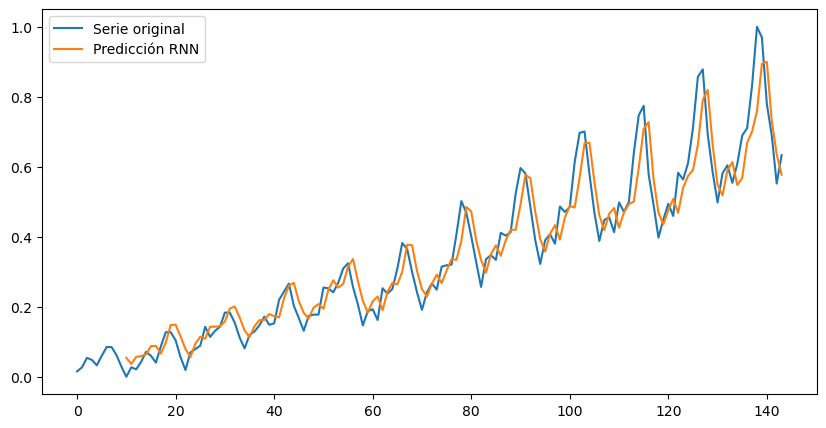

In [ ]:
# ============================================
# Entrenamiento
# ============================================
epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# ============================================
# Predicciones
# ============================================
y_pred = model(X).detach().numpy()

plt.figure(figsize=(10,5))
plt.plot(series, label="Serie original")
plt.plot(range(seq_length, len(y_pred)+seq_length), y_pred, label="Predicción RNN")
plt.legend()
plt.show()

# Ejemplo LTSM

### Keras

In [ ]:
# ============================
# Importar librerías
# ============================
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.utils import to_categorical

# ============================
# Datos y vocabulario
# ============================
text = "hello"
chars = sorted(list(set(text)))   # ['e','h','l','o']
vocab_size = len(chars)           # 4

# Mapear char -> índice
char2idx = {ch:i for i,ch in enumerate(chars)}
idx2char = {i:ch for ch,i in char2idx.items()}

# Convertir texto a índices
indices = [char2idx[ch] for ch in text]

# Crear secuencias de entrada y salida
# X: caracter actual, y: siguiente caracter
X = indices[:-1]  # [1,0,2,2] -> h,e,l,l
y = indices[1:]   # [0,2,2,3] -> e,l,l,o

# Convertir a formato one-hot para la salida
y = to_categorical(y, num_classes=vocab_size)  # shape (4, vocab_size)

In [ ]:
# ============================
# Preparar entrada para LSTM
# ============================
# LSTM espera input shape = (batch_size, timesteps, input_dim)
# En este ejemplo, tomamos timesteps=1 (un carácter por paso)
X = np.array(X).reshape((len(X), 1))  # shape (4,1)

# ============================
# Definir modelo LSTM
# ============================
embedding_dim = 4   # dimensión del embedding de cada carácter
hidden_size = 8     # número de neuronas en la capa LSTM

model = Sequential()

# Capa de embedding para convertir índices de caracteres en vectores densos
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=1))

# Capa LSTM
model.add(LSTM(hidden_size, return_sequences=False, return_state=False))

# Capa densa de salida con softmax
model.add(Dense(vocab_size, activation='softmax'))

# Compilar el modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


C:\Users\Flavio\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# ============================
# Entrenar modelo
# ============================
model.fit(X, y, epochs=200, verbose=0)  # Entrenamiento silencioso


# ============================
# Probar el modelo: generar texto
# ============================
print("\n=== Generación paso a paso ===")
input_char = 'h'
for _ in range(5):
    x_input = np.array([char2idx[input_char]]).reshape(1,1)  # shape (1,1)
    y_pred = model.predict(x_input, verbose=0)
    idx_pred = np.argmax(y_pred)
    next_char = idx2char[idx_pred]
    print(f"{input_char} -> {next_char}")
    input_char = next_char  # para siguiente predicción


=== Generación paso a paso ===
h -> e
e -> l
l -> l
l -> l
l -> l


In [ ]:
# ============================
# Mostrar estructura del modelo
# ============================
print("=== Estructura de la LSTM ===")
model.summary()  # imprime todas las capas, shapes y número de parámetros por capa

# ============================
# Imprimir número total de parámetros
# ============================
total_params = model.count_params()
print("\nNúmero total de parámetros del modelo:", total_params)

# # ============================
# # Imprimir pesos y biases de la capa LSTM
# # ============================
# lstm_layer = model.layers[1]  # segunda capa es LSTM
# weights = lstm_layer.get_weights()

# W_ih = weights[0]  # pesos de entrada a las puertas
# W_hh = weights[1]  # pesos recurrentes
# b = weights[2]     # biases (combinados i,f,c,o)

# print("\n=== Parámetros internos de la LSTM ===")
# print("W_ih (input -> hidden) shape:", W_ih.shape)
# print(W_ih)
# print("\nW_hh (hidden -> hidden) shape:", W_hh.shape)
# print(W_hh)
# print("\nBiases (i,f,c,o) shape:", b.shape)
# print(b)

=== Estructura de la LSTM ===


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 1, 4)                │              16 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 8)                   │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,406 (5.50 KB)

 Trainable params: 468 (1.83 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 938 (3.67 KB)


Número total de parámetros del modelo: 468


---
### Cálculo del número de parámetros por capa


#### Capa Embedding
- Fórmula general:  
$$
\text{Parámetros} = \text{vocab\_size} \times \text{embedding\_dim}
$$
- En este ejemplo:  
  - vocab_size = 4  
  - embedding_dim = 4  
$$
4 \times 4 = 16
$$
> Cada fila de la matriz de embedding corresponde a un carácter y se aprende durante el entrenamiento.

---

#### Capa LSTM
- Fórmula general:  
$$
\text{Parámetros} = 4 \times \big[ \text{hidden\_size} \times (\text{hidden\_size} + \text{input\_size}) + \text{hidden\_size} \big]
$$
donde:
- $n = \text{hidden\_size}$ : número de neuronas en la capa LSTM
- $m = \text{input\_size}$ : tamaño del vector de entrada a la LSTM (por ejemplo, `embedding_dim` si se usa embedding)  
- Explicación:  
  - La LSTM tiene **4 puertas** internas: input (i), forget (f), cell (c), output (o).  
  - Cada puerta tiene:
    - Pesos de entrada $W_{ih}$ de tamaño $(\text{input\_size}, \text{hidden\_size})$  
    - Pesos recurrentes $W_{hh}$ de tamaño $(\text{hidden\_size}, \text{hidden\_size})$  
    - Bias de tamaño $\text{hidden\_size}$  
- En este ejemplo:  
  - input_size = embedding_dim = 4  
  - hidden_size = 8  
$$
4 \times \big[ 8 \times (8 + 4) + 8 \big] = 4 \times 104 = 416
$$
> Coincide con los parámetros que muestra Keras.

---

#### Capa Dense
- Fórmula general:  
$$
\text{Parámetros} = \text{input\_units} \times \text{output\_units} + \text{output\_units}
$$
- En este ejemplo:  
  - input_units = 8 (hidden_size de la LSTM)  
  - output_units = 4 (vocab_size)  
$$
8 \times 4 + 4 = 36
$$
> Incluye los pesos y el bias de la capa de salida.


### PyTorch

In [ ]:
# ============================
# Importar librerías
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ============================
# Datos y vocabulario
# ============================
text = "hello"
chars = sorted(list(set(text)))   # ['e','h','l','o']
vocab_size = len(chars)           # 4

# Mapear char -> índice
char2idx = {ch:i for i,ch in enumerate(chars)}
idx2char = {i:ch for ch,i in char2idx.items()}

# Convertir texto a índices
indices = [char2idx[ch] for ch in text]

# Crear secuencias de entrada y salida
# X: caracter actual, y: siguiente caracter
X = indices[:-1]  # [1,0,2,2] -> h,e,l,l
y = indices[1:]   # [0,2,2,3] -> e,l,l,o

# Convertir a tensores
X = torch.tensor(X, dtype=torch.long).reshape(-1,1)  # shape (4,1)
y = torch.tensor(y, dtype=torch.long)               # shape (4,)

# ============================
# Definir modelo LSTM
# ============================
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.softmax = nn.Softmax(dim=1)
        self.hidden_size = hidden_size

    def forward(self, x, hidden=None):
        # x: (batch_size, timesteps)
        x = self.embedding(x)  # (batch_size, timesteps, embedding_dim)
        if hidden is None:
            out, hidden = self.lstm(x)  # out: (batch_size, timesteps, hidden_size)
        else:
            out, hidden = self.lstm(x, hidden)
        out = out[:, -1, :]           # tomar última salida temporal
        out = self.fc(out)            # capa densa
        out = self.softmax(out)       # softmax
        return out, hidden

# ============================
# Inicializar modelo, pérdida y optimizador
# ============================
embedding_dim = 4
hidden_size = 8

model = LSTMModel(vocab_size, embedding_dim, hidden_size)
criterion = nn.CrossEntropyLoss()  # combina softmax + log loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ============================
# Entrenar modelo
# ============================
epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs, _ = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 50/200, Loss: 1.0337
Epoch 100/200, Loss: 0.9685
Epoch 150/200, Loss: 0.9599
Epoch 200/200, Loss: 0.9581


In [ ]:
# ============================
# Generar texto paso a paso
# ============================
print("\n=== Generación paso a paso ===")
input_char = 'h'
hidden = None
for _ in range(5):
    x_input = torch.tensor([[char2idx[input_char]]], dtype=torch.long)
    y_pred, hidden = model(x_input, hidden)
    idx_pred = torch.argmax(y_pred, dim=1).item()
    next_char = idx2char[idx_pred]
    print(f"{input_char} -> {next_char}")
    input_char = next_char


=== Generación paso a paso ===
h -> e
e -> l
l -> l
l -> l
l -> l


In [ ]:
# ============================
# Mostrar estructura del modelo
# ============================
print("\n=== Estructura de la LSTM ===")
print(model)

# ============================
# Imprimir número total de parámetros
# ============================
total_params = sum(p.numel() for p in model.parameters())
print("\nNúmero total de parámetros del modelo:", total_params)

# # ============================
# # Inspeccionar pesos y biases de la LSTM
# # ============================
# for name, param in model.lstm.named_parameters():
#     print(f"{name}: {param.shape}")


=== Estructura de la LSTM ===
LSTMModel(
  (embedding): Embedding(4, 4)
  (lstm): LSTM(4, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=4, bias=True)
  (softmax): Softmax(dim=1)
)

Número total de parámetros del modelo: 500


### Desglose detallado de parámetros de la LSTM en PyTorch

#### Capa Embedding
- Fórmula:  
$$
\text{Parámetros} = \text{vocab\_size} \times \text{embedding\_dim}
$$
- Ejemplo:  
  - vocab_size = 4  
  - embedding_dim = 4  
$$
4 \times 4 = 16
$$
> Cada fila de la matriz de embedding corresponde a un carácter y se aprende durante el entrenamiento.

---

#### Capa LSTM
- Fórmula general:  
$$
\text{Parámetros LSTM} = 4 \times \big[ \text{hidden\_size} \times (\text{hidden\_size} + \text{input\_size}) + (\text{hidden\_size} \times 2) \big]
$$

- Explicación:  
  - `hidden_size`: número de neuronas de la LSTM (8)  
  - `input_size`: tamaño de la entrada a la LSTM (embedding_dim = 4)  
  - Factor 4: corresponde a las **4 puertas internas**: input (i), forget (f), cell (g), output (o)  
  - Cada puerta tiene:
    - Pesos de entrada \(W_{ih}\): (hidden_size × input_size)  
    - Pesos recurrentes \(W_{hh}\): (hidden_size × hidden_size)  
    - Bias de entrada: (hidden_size)  
    - Bias recurrentes: (hidden_size)  

- Sustituyendo valores:
$$
4 \times \big[ 8 \times (8 + 4) + (8 \times 2) \big] = 4 \times 104 = 448
$$

- Desglose por tipo:

| Tipo de parámetro       | Forma       | Cantidad |
|-------------------------|------------|----------|
| Pesos de entrada W_ih   | (8, 4)     | 32 × 4 puertas = 128 |
| Pesos recurrentes W_hh  | (8, 8)     | 64 × 4 puertas = 256 |
| Bias de entrada         | (8)        | 8 × 4 puertas = 32 |
| Bias recurrentes       | (8)        | 8 × 4 puertas = 32 |
| **Total LSTM**          | -          | 448 |

---

#### Capa Dense
- Fórmula:  
$$
\text{Parámetros} = \text{hidden\_size} \times \text{vocab\_size} + \text{vocab\_size}
$$
- Ejemplo:  
  - hidden_size = 8  
  - vocab_size = 4  
$$
8 \times 4 + 4 = 36
$$
> Incluye pesos y bias de la capa de salida.

---

#### Resumen de parámetros del modelo

| Capa      | Parámetros |
|-----------|-----------|
| Embedding | 16        |
| LSTM      | 448       |
| Dense     | 36        |
| **Total** | 500       |


### Predicción de la serie temporal *AirPassengers* con LSTM

En esta sección se implementa un modelo **LSTM (Long Short-Term Memory)** para predecir la evolución de la serie histórica *AirPassengers* (1949–1960).  
El flujo del código es el siguiente:

1. **Carga y preprocesamiento de datos**  
   - Se obtiene el dataset real de pasajeros mensuales.  
   - Se normaliza la serie y se generan **ventanas deslizantes** para crear los pares entrada–salida.


2. **Definición del modelo LSTM**  
   - Una capa recurrente LSTM con `hidden_size=32`.  
   - Una capa lineal que proyecta el último estado oculto a la salida (predicción de pasajeros).  


3. **Entrenamiento**  
   - Optimización con **Adam** y función de pérdida **MSE**.  
   - Entrenamiento por mini-batches con `batch_size=16`.  


4. **Evaluación y resultados**  
   - Se muestran la arquitectura del modelo, el número de parámetros entrenables y las formas de `X` y `y`.  
   - Se visualiza la serie original junto con las predicciones generadas por la LSTM.  
   - Se reporta el **MSE en la escala original** de los pasajeros.  

Este ejemplo sirve como introducción didáctica al uso de LSTM en **series temporales reales**.


In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# ----------------------------
# Reproducibilidad (opcional)
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ----------------------------
# Cargar y normalizar datos
# ----------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])         # solo la columna "Passengers"
series = df.values.astype("float32")       # (144, 1)

# Normalización manual a [0,1]
min_val = series.min()
max_val = series.max()
series_norm = (series - min_val) / (max_val - min_val)   # (144,1)

# Convertir a vector 1D para facilitar
series_norm = series_norm.reshape(-1)  # (144,)

# ----------------------------
# Crear secuencias (ventanas)
# ----------------------------
def create_sequences(data, seq_len):
    """
    data: array 1D
    seq_len: cantidad de pasos pasados usados como entrada
    devuelve:
      X -> np.array shape (num_samples, seq_len, 1)
      y -> np.array shape (num_samples, 1)
    """
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        x = data[i : i + seq_len]
        y = data[i + seq_len]
        xs.append(x)
        ys.append(y)
    X = np.array(xs)
    y = np.array(ys)
    # añadir dimensión de característica (univariada)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    y = y.reshape((y.shape[0], 1))
    return X, y

SEQ_LEN = 12    # por ejemplo: usar 12 meses para predecir el siguiente
X_np, y_np = create_sequences(series_norm, SEQ_LEN)

# ----------------------------
# Convertir a tensores y DataLoader
# ----------------------------
X = torch.tensor(X_np, dtype=torch.float32)   # (num_samples, seq_len, input_size)
y = torch.tensor(y_np, dtype=torch.float32)   # (num_samples, 1)

print("Forma X (tensor):", X.shape)
print("Forma y (tensor):", y.shape)

BATCH_SIZE = 16
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

Forma X (tensor): torch.Size([132, 12, 1])
Forma y (tensor): torch.Size([132, 1])


## Tamaño de la base de datos

El conjunto de datos **AirPassengers** contiene el número mensual de pasajeros de aerolíneas internacionales desde **enero de 1949 hasta diciembre de 1960**, es decir:

- **144 observaciones** (12 años × 12 meses).
- Es una serie temporal **univariada** (solo tiene una variable: el número de pasajeros).

Tras normalizar y convertir la serie en pares `(X, y)` para entrenamiento de la LSTM:

- `X` corresponde a secuencias de tamaño fijo (por ejemplo, 12 meses pasados).
- `y` es el valor a predecir (el siguiente mes).

Por lo tanto, el tamaño final de `X` y `y` depende de la **ventana temporal** elegida.  
Si usamos una ventana de 12 pasos, se obtienen **132 muestras** (144 – 12).


In [ ]:
# ----------------------------
# Definir modelo LSTM
# ----------------------------
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1, dropout=0.0):
        super().__init__()
        # LSTM: devuelve salida por cada paso y el último estado oculto/celular
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        # Capa final que toma el último estado oculto y proyecta al output
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        out: (batch, output_size)
        """
        out, (h_n, c_n) = self.lstm(x)   # out: (batch, seq_len, hidden_size)
        last = out[:, -1, :]             # tomar salida del último paso temporal -> (batch, hidden_size)
        out = self.fc(last)              # (batch, output_size)
        return out

# ----------------------------
# Instanciar modelo, criterio y optimizador
# ----------------------------
INPUT_SIZE = 1
HIDDEN_SIZE = 32
NUM_LAYERS = 1
OUTPUT_SIZE = 1
LR = 0.01

model = LSTMPredictor(input_size=INPUT_SIZE,
                      hidden_size=HIDDEN_SIZE,
                      num_layers=NUM_LAYERS,
                      output_size=OUTPUT_SIZE)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ----------------------------
# Imprimir estructura y parámetros
# ----------------------------
print("\n=== Estructura del modelo ===")
print(model)

# print("\n=== Desglose de parámetros entrenables ===")
# total_params = 0
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         n = param.numel()
#         total_params += n
#         print(f"{name:30s} | shape: {tuple(param.shape):20s} | params: {n:6d}")
# print(f"\nNúmero total de parámetros entrenables: {total_params}")

print("\n=== Desglose de parámetros entrenables ===")
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        n = param.numel()
        total_params += n
        shape_str = str(tuple(param.shape))  # convertir a string
        print(f"{name:30s} | shape: {shape_str:20s} | params: {n:6d}")
print(f"\nNúmero total de parámetros entrenables: {total_params}")


=== Estructura del modelo ===
LSTMPredictor(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

=== Desglose de parámetros entrenables ===
lstm.weight_ih_l0              | shape: (128, 1)             | params:    128
lstm.weight_hh_l0              | shape: (128, 32)            | params:   4096
lstm.bias_ih_l0                | shape: (128,)               | params:    128
lstm.bias_hh_l0                | shape: (128,)               | params:    128
fc.weight                      | shape: (1, 32)              | params:     32
fc.bias                        | shape: (1,)                 | params:      1

Número total de parámetros entrenables: 4513



Iniciando entrenamiento...
Epoch   1/120  -  Loss (prom): 0.074639
Epoch  10/120  -  Loss (prom): 0.007364
Epoch  20/120  -  Loss (prom): 0.005105
Epoch  30/120  -  Loss (prom): 0.003432
Epoch  40/120  -  Loss (prom): 0.002669
Epoch  50/120  -  Loss (prom): 0.002494
Epoch  60/120  -  Loss (prom): 0.001940
Epoch  70/120  -  Loss (prom): 0.001791
Epoch  80/120  -  Loss (prom): 0.002144
Epoch  90/120  -  Loss (prom): 0.001219
Epoch 100/120  -  Loss (prom): 0.002219
Epoch 110/120  -  Loss (prom): 0.001123
Epoch 120/120  -  Loss (prom): 0.001112


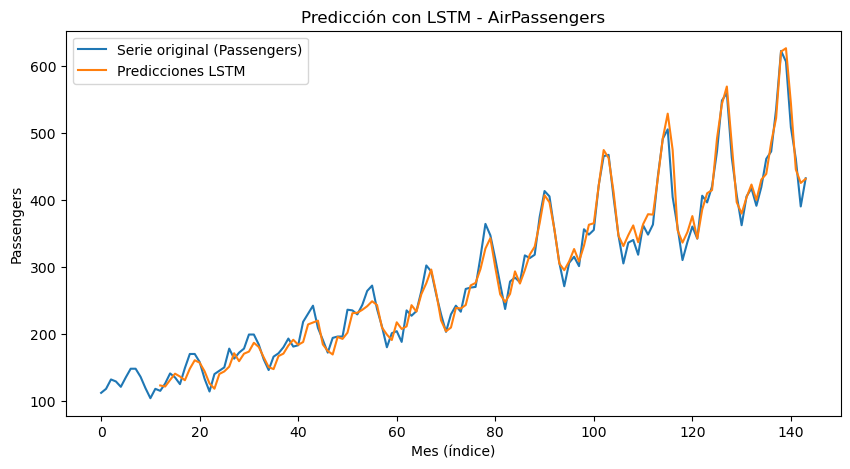


MSE en escala original: 258.7045


In [ ]:
# ----------------------------
# Entrenamiento 
# ----------------------------
EPOCHS = 120
print("\nIniciando entrenamiento...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []
    for xb, yb in dataloader:
        optimizer.zero_grad()
        y_pred = model(xb)           # (batch, 1)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  -  Loss (prom): {np.mean(epoch_losses):.6f}")

# ----------------------------
# Evaluación: predicción sobre todo el set
# ----------------------------
model.eval()
with torch.no_grad():
    preds = model(X).cpu().numpy()   # (num_samples, 1)

# Volver a la escala original
preds_rescaled = preds * (max_val - min_val) + min_val
y_rescaled = y_np * (max_val - min_val) + min_val

# Graficar serie original y predicciones (alineadas)
plt.figure(figsize=(10,5))
# Serie original (toda la serie)
plt.plot(df.values, label="Serie original (Passengers)")

# Predicciones: están alineadas empezando en index = SEQ_LEN
start = SEQ_LEN
plt.plot(range(start, start + len(preds_rescaled)), preds_rescaled.flatten(), label="Predicciones LSTM")
plt.xlabel("Mes (índice)")
plt.ylabel("Passengers")
plt.legend()
plt.title("Predicción con LSTM - AirPassengers")
plt.show()

# ----------------------------
# Métrica final (MSE en escala original)
# ----------------------------
mse_original_scale = np.mean((preds_rescaled.flatten() - y_rescaled.flatten())**2)
print(f"\nMSE en escala original: {mse_original_scale:.4f}")

# ----------------------------
# Fin
# ----------------------------

# Ejemplo GRU

## Predicción de la palabra *"hello"* usando una red GRU en Keras

En este ejemplo se construye y entrena una red neuronal recurrente basada en **GRU** para aprender la secuencia de caracteres de la palabra *"hello"*.  
El código incluye:
- Preparación de los datos con *one-hot encoding*.  
- Definición de la red GRU y una capa densa de salida.  
- Visualización de la estructura del modelo y cálculo manual de parámetros.  
- Entrenamiento y predicción carácter a carácter.  


In [ ]:
# ====================================================
# Importar librerías necesarias
# ====================================================
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.utils import to_categorical

# ====================================================
# Preparar los datos (problema "Hello")
# ====================================================
# Queremos que la red aprenda a predecir la secuencia de letras de la palabra "hello"
# Ejemplo: "h e l l o"
# Entrada:  h e l l
# Salida:   e l l o

# Definimos el vocabulario
chars = ['h', 'e', 'l', 'o']
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# Convertir la palabra "hello" en índices
word = "hello"
seq_indices = [char_to_idx[c] for c in word]  # -> [0,1,2,2,3]

# Entradas (X): "hell"
# Salidas   (y): "ello"
X_data = seq_indices[:-1]   # [0,1,2,2]
y_data = seq_indices[1:]    # [1,2,2,3]

# One-hot encoding
X = to_categorical(X_data, num_classes=len(chars))  # (4, 4)
y = to_categorical(y_data, num_classes=len(chars))  # (4, 4)

# Reshape para RNN (batch, timesteps, features)
X = X.reshape(1, X.shape[0], X.shape[1])  # (1, 4, 4)
y = y.reshape(1, y.shape[0], y.shape[1])  # (1, 4, 4)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (1, 4, 4)
Forma de y: (1, 4, 4)


In [ ]:
# ====================================================
# Construir la red GRU
# ====================================================
model = Sequential()
model.add(GRU(units=8, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))
model.add(Dense(len(chars), activation='softmax'))

# ====================================================
# Compilar el modelo
# ====================================================
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# ====================================================
# Ver la estructura del modelo
# ====================================================
print("\nResumen de la red GRU:")
model.summary()


Resumen de la red GRU:


C:\Users\Flavio\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 4, 8)                │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4, 4)                │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 372 (1.45 KB)

 Trainable params: 372 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ====================================================
# Cálculo del número de parámetros en GRU
# ====================================================
# Fórmula del número de parámetros en GRU:
# Parámetros = 3 * (units * (units + input_dim + 1))
# donde:
# - "3" viene de los 3 "gates" de GRU (reset, update, candidate)
# - "units": número de neuronas en la capa GRU
# - "input_dim": tamaño de la entrada
# - "1": corresponde al bias de cada puerta

input_dim = X.shape[2]   # = 4 (one-hot de "hello")
units = 8                # número de neuronas GRU

params_gru = 3 * (units * (units + input_dim + 1))
params_dense = (units * len(chars)) + len(chars)

print(f"\nCálculo manual de parámetros:")
print(f"GRU:   3 * ({units} * ({units} + {input_dim} + 1)) = {params_gru}")
print(f"Dense: ({units} * {len(chars)}) + {len(chars)} = {params_dense}")
print(f"Total = {params_gru + params_dense}")


Cálculo manual de parámetros:
GRU:   3 * (8 * (8 + 4 + 1)) = 312
Dense: (8 * 4) + 4 = 36
Total = 348


## Cálculo del número de parámetros en una GRU

Una capa **GRU** tiene tres compuertas principales:  
- **Compuerta de actualización** ($z$)  
- **Compuerta de reinicio** ($r$)  
- **Candidato a estado oculto** ($\tilde{h}$)  

Para cada compuerta se necesitan dos conjuntos de pesos y un sesgo:  

1. **Pesos de entrada**: $W \in \mathbb{R}^{d \times h}$, donde $d$ es la dimensión de la entrada y $h$ el tamaño del estado oculto.  
2. **Pesos recurrentes**: $U \in \mathbb{R}^{h \times h}$.  
3. **Bias**: $b \in \mathbb{R}^{h}$.  

En total, para **cada compuerta**:  
$ \text{Parámetros} = d \cdot h + h \cdot h + h $  

Como existen **3 compuertas**, la fórmula final es:  
$ \text{Parámetros totales GRU} = 3 \cdot (d \cdot h + h^2 + h) $  

Finalmente, si hay una capa densa de salida ($h \to o$):  
$ \text{Parámetros capa densa} = h \cdot o + o $  

Donde:  
- $d$: dimensión de la entrada (*input\_size*)  
- $h$: número de unidades ocultas (*hidden\_size*)  
- $o$: número de salidas (*output\_size*)  


In [ ]:
# ====================================================
# Entrenamiento del modelo
# ====================================================
print("\nEntrenando la red...")
model.fit(X, y, epochs=200, verbose=0)

# ====================================================
# Evaluación y predicción
# ====================================================
pred = model.predict(X)
pred_indices = np.argmax(pred, axis=2)

print("\nPredicción (índices):", pred_indices)
print("Predicción (caracteres):", [idx_to_char[i] for i in pred_indices[0]])


Entrenando la red...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step

Predicción (índices): [[1 2 2 2]]
Predicción (caracteres): ['e', 'l', 'l', 'l']


## Predicción de la palabra *"hello"* con una red GRU en PyTorch

En este ejemplo se implementa una red neuronal recurrente basada en **GRU** para aprender la secuencia de caracteres de la palabra *"hello"*.  
El código incluye: preparación de datos con *one-hot encoding*, definición del modelo, impresión de su estructura y parámetros, entrenamiento y predicción carácter a carácter.  


In [ ]:
# ============================================
# Importar librerías necesarias
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Fijar semilla para reproducibilidad
torch.manual_seed(42)

# ============================================
# Preparación de los datos
# ============================================

# Vocabulario: letras únicas en la palabra "hello"
chars = ['h', 'e', 'l', 'o']
char2idx = {ch: i for i, ch in enumerate(chars)}   # mapeo letra -> índice
idx2char = {i: ch for ch, i in char2idx.items()}   # mapeo índice -> letra
vocab_size = len(chars)

print("Vocabulario:", char2idx)

# Secuencia de entrada y salida
# "hell" -> "ello"
input_seq = "hell"
target_seq = "ello"

# Convertir a índices
x_data = [char2idx[ch] for ch in input_seq]
y_data = [char2idx[ch] for ch in target_seq]

print("Entrada (índices):", x_data)
print("Salida  (índices):", y_data)

# One-hot encoding para la entrada
x_onehot = np.eye(vocab_size)[x_data]  # matriz identidad usada como codificación one-hot

# Convertir a tensores de PyTorch
X = torch.tensor([x_onehot], dtype=torch.float32)  # (batch=1, seq_len=4, input_size=4)
Y = torch.tensor([y_data], dtype=torch.long)       # (batch=1, seq_len=4)

print("Forma de X:", X.shape)
print("Forma de Y:", Y.shape)

Vocabulario: {'h': 0, 'e': 1, 'l': 2, 'o': 3}
Entrada (índices): [0, 1, 2, 2]
Salida  (índices): [1, 2, 2, 3]
Forma de X: torch.Size([1, 4, 4])
Forma de Y: torch.Size([1, 4])


In [ ]:
# ============================================
# Definir el modelo GRU
# ============================================

class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(GRUNet, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Capa GRU
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)

        # Capa lineal de salida
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        # out: (batch, seq_len, hidden_size)
        out, hidden = self.gru(x, hidden)

        # Pasar cada estado oculto por la capa lineal
        out = self.fc(out)  # (batch, seq_len, output_size)
        return out, hidden

# Parámetros del modelo
input_size = vocab_size   # tamaño de one-hot = 4
hidden_size = 8           # tamaño del estado oculto
num_layers = 1            # capas GRU
output_size = vocab_size  # número de clases (caracteres)

model = GRUNet(input_size, hidden_size, num_layers, output_size)

# ============================================
# Mostrar estructura y número de parámetros
# ============================================
print("\nEstructura del modelo:\n")
print(model)

# Contar parámetros entrenables
print("\nParámetros entrenables:\n")
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        n = param.numel()
        total_params += n
        print(f"{name:30s} | shape: {tuple(param.shape)} | params: {n}")
print(f"\nNúmero total de parámetros: {total_params}\n")

# ============================================
# Definir función de pérdida y optimizador
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


Estructura del modelo:

GRUNet(
  (gru): GRU(4, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=4, bias=True)
)

Parámetros entrenables:

gru.weight_ih_l0               | shape: (24, 4) | params: 96
gru.weight_hh_l0               | shape: (24, 8) | params: 192
gru.bias_ih_l0                 | shape: (24,) | params: 24
gru.bias_hh_l0                 | shape: (24,) | params: 24
fc.weight                      | shape: (4, 8) | params: 32
fc.bias                        | shape: (4,) | params: 4

Número total de parámetros: 372



In [ ]:
# ============================================
# Entrenamiento
# ============================================
epochs = 200
for epoch in range(epochs+1):
    optimizer.zero_grad()

    # Forward
    output, hidden = model(X)
    loss = criterion(output.reshape(-1, vocab_size), Y.view(-1))

    # Backward
    loss.backward()
    optimizer.step()

    # Mostrar cada 20 épocas
    if epoch % 20 == 0:
        pred = output.argmax(dim=2).squeeze().detach().numpy()
        pred_str = ''.join([idx2char[i] for i in pred])
        target_str = ''.join([idx2char[i] for i in y_data])
        print(f"Época {epoch:3d} | Pérdida: {loss.item():.4f} | Predicción: {pred_str} | Real: {target_str}")

Época   0 | Pérdida: 1.2074 | Predicción: eelo | Real: ello
Época  20 | Pérdida: 0.6063 | Predicción: ello | Real: ello
Época  40 | Pérdida: 0.1329 | Predicción: ello | Real: ello
Época  60 | Pérdida: 0.0335 | Predicción: ello | Real: ello
Época  80 | Pérdida: 0.0164 | Predicción: ello | Real: ello
Época 100 | Pérdida: 0.0108 | Predicción: ello | Real: ello
Época 120 | Pérdida: 0.0080 | Predicción: ello | Real: ello
Época 140 | Pérdida: 0.0063 | Predicción: ello | Real: ello
Época 160 | Pérdida: 0.0051 | Predicción: ello | Real: ello
Época 180 | Pérdida: 0.0042 | Predicción: ello | Real: ello
Época 200 | Pérdida: 0.0036 | Predicción: ello | Real: ello


### Predicción de la serie AirPassengers con una red GRU en PyTorch

En este ejemplo se implementa una red neuronal recurrente basada en **GRU** para modelar y predecir la evolución de la serie temporal *AirPassengers*.  
El código incluye: preparación de datos en secuencias, definición de la red, impresión de su estructura y parámetros, entrenamiento y comparación entre valores reales y predichos.  


In [ ]:
# ============================================
# Predicción de la serie AirPassengers con GRU en PyTorch
# ============================================

# ----------------------------
# Importar librerías
# ----------------------------
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Cargar dataset real
# ----------------------------
# Dataset AirPassengers (1949-1960)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])  # solo la columna "#Passengers"

# Normalizar la serie en [0,1] para facilitar entrenamiento
scaler = MinMaxScaler()
series = scaler.fit_transform(df.values.astype(float))

print("Tamaño de la serie:", series.shape)

# ----------------------------
# Función para crear secuencias (ventanas deslizantes)
# ----------------------------
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 12  # usar 12 meses para predecir el siguiente
X, y = create_sequences(series, seq_length)

# Convertir a tensores de PyTorch
X = torch.tensor(X).float()   # (num_muestras, seq_length, 1)
y = torch.tensor(y).float()   # (num_muestras, 1)

print("Forma de X:", X.shape)  # (N, 12, 1)
print("Forma de y:", y.shape)  # (N, 1)

Tamaño de la serie: (144, 1)
Forma de X: torch.Size([132, 12, 1])
Forma de y: torch.Size([132, 1])


In [ ]:
# ----------------------------
# Definir la red GRU
# ----------------------------
class GRUPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(GRUPredictor, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # out: (batch, seq_len, hidden_size)
        out, _ = self.gru(x)
        # tomar solo el último estado oculto
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# Crear modelo, función de pérdida y optimizador
model = GRUPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ----------------------------
# Imprimir estructura de la red
# ----------------------------
print("\nEstructura de la red:")
print(model)

# ----------------------------
# Calcular número de parámetros entrenables
# ----------------------------
print("\nDetalle de parámetros entrenables:")
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        n = param.numel()
        print(f"{name:30s} | shape: {tuple(param.shape)} | params: {n}")
        total_params += n
print(f"\nNúmero total de parámetros entrenables: {total_params}")


Estructura de la red:
GRUPredictor(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Detalle de parámetros entrenables:
gru.weight_ih_l0               | shape: (96, 1) | params: 96
gru.weight_hh_l0               | shape: (96, 32) | params: 3072
gru.bias_ih_l0                 | shape: (96,) | params: 96
gru.bias_hh_l0                 | shape: (96,) | params: 96
fc.weight                      | shape: (1, 32) | params: 32
fc.bias                        | shape: (1,) | params: 1

Número total de parámetros entrenables: 3393


Epoch 10/50, Loss: 0.035220
Epoch 20/50, Loss: 0.015404
Epoch 30/50, Loss: 0.007960
Epoch 40/50, Loss: 0.006300
Epoch 50/50, Loss: 0.004985


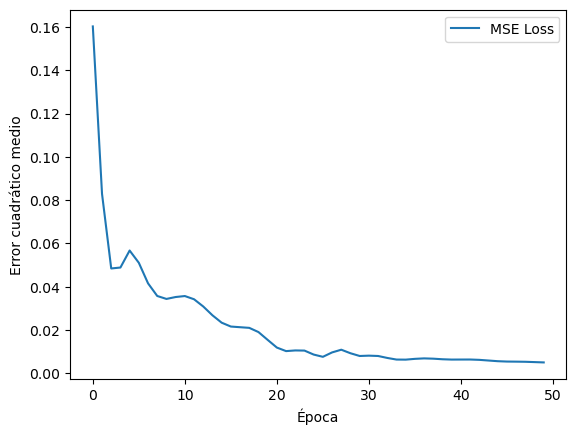

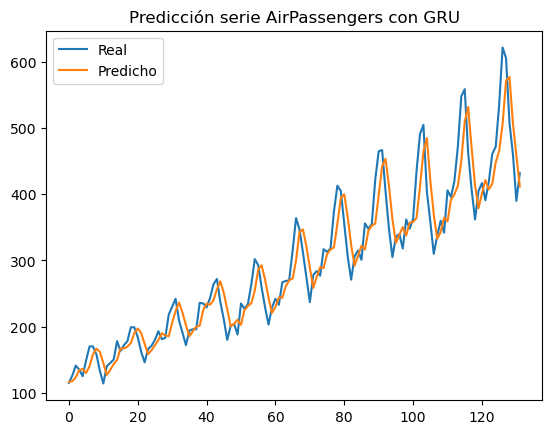

In [ ]:
# ----------------------------
# Entrenamiento 
# ----------------------------
epochs = 50
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# ----------------------------
# Visualizar pérdida
# ----------------------------
plt.plot(losses, label="MSE Loss")
plt.xlabel("Época")
plt.ylabel("Error cuadrático medio")
plt.legend()
plt.show()

# ----------------------------
# Evaluar predicción
# ----------------------------
with torch.no_grad():
    y_pred = model(X).numpy()

# Invertir normalización para interpretar resultados
y_real = scaler.inverse_transform(y.numpy())
y_pred_inv = scaler.inverse_transform(y_pred)

plt.plot(y_real, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.title("Predicción serie AirPassengers con GRU")
plt.show()

# Transfer Learning

In [ ]:
# =========================================
# TRANSFER LEARNING RÁPIDO - Feature Extraction
# CON RESNET-50 Y CIFAR-10 (subset para pruebas)
# =========================================

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

# ----------------------------
# Configuración básica
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
num_classes = 10   # CIFAR-10 tiene 10 clases
num_epochs = 1     # solo prueba rápida

# ----------------------------
# Preparar CIFAR-10
# ----------------------------
# Tamaño reducido para prueba rápida
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # más rápido que 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Tomar solo un subset pequeño para acelerar
train_subset = Subset(train_dataset, list(range(500)))  # 500 imágenes
val_subset   = Subset(val_dataset, list(range(200)))    # 200 imágenes

dataloaders = {
    'train': DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True),
    'val': DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
}

# Mostrar tamaños de los datasets
print("Tamaños de los datasets (subset para prueba rápida):")
print(f"Train: {len(train_subset)} imágenes")
print(f"Validation: {len(val_subset)} imágenes")

Tamaños de los datasets (subset para prueba rápida):
Train: 500 imágenes
Validation: 200 imágenes


#### Arquitectura de **ResNet-50**

<img src="fig/Notebook/ResNet-50.png" alt="Mi imagen" width="700"/>

In [ ]:
# ----------------------------
# Cargar ResNet-50 preentrenada
# ----------------------------
model_pretrained = models.resnet50(pretrained=True)
print("\nArquitectura del modelo preentrenado (ResNet-50):")
print("Entrenada con el Dataset: ImageNet, que contiene: ")
print("   - Cerca de 1.2 millones de imágenes de entrenamiento y")
print("   - 1000 clases de objetos.\n\n")

#print(model_pretrained)
print("Capa FC: ",model_pretrained.fc)

C:\Users\Flavio\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Flavio\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Arquitectura del modelo preentrenado (ResNet-50):
Entrenada con el Dataset: ImageNet, que contiene: 
   - Cerca de 1.2 millones de imágenes de entrenamiento y
   - 1000 clases de objetos.


Capa FC:  Linear(in_features=2048, out_features=1000, bias=True)


---

#### FINE TUNING

En PyTorch, cada tensor que forma parte de los parámetros de un modelo tiene un atributo llamado `requires_grad`:

> param.requires_grad  # True o False

- **True** → PyTorch calculará gradientes para este parámetro cuando llames `loss.backward()`.
- **False** → No se calcularán gradientes para este parámetro; no se actualizará durante `optimizer.step()`.


In [ ]:
# ----------------------------
# Feature Extraction
# ----------------------------
# Congelar todos los parámetros
for param in model_pretrained.parameters():
    param.requires_grad = False     # Le dice a PyTorch que no calcule gradientes para este parámetro durante la retropropagación.
                                    # En otras palabras, estos parámetros NO se actualizarán durante el entrenamiento.

# Reemplazar la capa final (fully connected)
num_features = model_pretrained.fc.in_features  # 2048 para ResNet-50
model_pretrained.fc = nn.Linear(num_features, num_classes)

model = model_pretrained.to(device)
print("\nArquitectura del modelo modificado para CIFAR-10:")
#print(model)
print("Capa FC: ",model.fc)


Arquitectura del modelo modificado para CIFAR-10:
Capa FC:  Linear(in_features=2048, out_features=10, bias=True)


In [ ]:
# ----------------------------
# Número de parámetros entrenables
# ----------------------------
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNúmero de parámetros que se ajustarán durante el entrenamiento: {trainable_params}")
print(f"Esto corresponde solo a la última capa FC: {num_features} entradas x {num_classes} salidas + {num_classes} bias")
print(f"2048*10 + 10 = {2048*10 + 10} parámetros")


Número de parámetros que se ajustarán durante el entrenamiento: 20490
Esto corresponde solo a la última capa FC: 2048 entradas x 10 salidas + 10 bias
2048*10 + 10 = 20490 parámetros


In [ ]:
# ----------------------------
# Definir loss y optimizador
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

# ----------------------------
# Entrenamiento
# ----------------------------
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-'*30)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders[phase].dataset)
        epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

print('\nEntrenamiento completado.')


Epoch 1/1
------------------------------


C:\Users\Flavio\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


train Loss: 2.2987 Acc: 0.1660
val Loss: 2.1894 Acc: 0.2500

Entrenamiento completado.


# FIN